# ImmoEliza Project: Machine Learning model for price prediction

In this notebook, we will build a model to predict real estate prices.


### The plan:

**Data Cleaning**
- ✅ DROP columns:  
  - locality and region -> redundant with zip code
  - type of glazing (3 possibilities, annoying, captured by energy)
  - type of heating (8 possibilities, annoying to do, somewhat captured by energy, 8k+ nulls + 1700 not specified. almost half empty...) 
  ❓Might want to come back to this


- ✅ Categoricals
  - correlated trio (build_year, building_state, energy): keep all of them, let lasso pick the winner. 
  - Building state : keep it as one column. lasso will figure it out. One hot encode possible, but the weight should take care of it, and it's simpler with one column


- ✅ Property type / property subtype : We group then one hot encode towards this:
    prop_type_num = 
      flat + studentFlat + loft + flatStudio
      house + masterHouse + mansion
      villa
      mixedBuilding
      duple + triplex
      penthouse
      others = chalet, bungalow, cottage, groundFloor





- ✅ Fill in nulls:
  has_terrace : if null -> false
  Before or after the split makes no difference, it's a hard choice.

💡 I could refine by dropping zipcode with very few properties.

Also, infer land area from garden area
also split into flat and houses.


- ✅ **SPLIT**
  split into X_train, X_test
  > don't forget to drop price from X



- ✅ **Target Encoding for the zipcode**
  My idea for now is to do this:
  df.groupby(zipcode) get the median price per m2 for that zipcode and write that to a new column for each row. Basically, instead of a zip code i use the median price per m2 for that zipcode.

  > DROP zipcode and price by m2 after this
  ❗Carefull here and below. When doing this, only calculate values for the train set, and map them to the test set. Don't recalculate a new value for the test set, otherwise, i'm leaking info from the test set, into itself. instead, transform the test set with the values from the train set


- ✅ **Filling Nulls**
  building state (mode)
  number of bedrooms (mode)
  furnished (mode)
  number of facade (mode)

  build year, (median)
  energy (median)
  land area (median)

  ❗Carefull When doing this, only calculate values for the train set, and map them to the test set. Don't recalculate a new value for the test set, otherwise, i'm leaking info from the test set, into itself. instead, transform the test set with the values from the train set


**Polynomial Expansion**
Before standardisation because everything used needs to be normalised.


**Standardise**

**Lasso Regression Model**

Idea : loop through possible polynomial degrees. hyperparameter search
**Test and score the model**


In [1]:

## Imports
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
plt.style.use('default') # seaborn, ggplot


# For the Model:
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # for the standardisation
from sklearn.linear_model import Lasso  # for the lasso regression

# to redo the clean, start from clean_data_for_analysis.csv

# Cleaning done, working from model data
data_file = '../data/clean_data_for_model.csv'
df = pd.read_csv(data_file)
df['furnished'] = df['furnished'].astype('bool') # not sure why that got eaten


In [2]:
## Data Cleaned : commented out so i can skip it 

""" 

### Dropping columns
df = df.drop(['locality', 'region', 'type_of_glazing', 'type_of_heating'], axis=1)

### resetting types
df['furnished'] = df['furnished'].astype('boolean')
df['has_terrace'] = df['has_terrace'].astype('boolean')
df['zip_code'] = df['zip_code'].astype('int')

## Fill in null in has terrace:
df["has_terrace"] = df["has_terrace"].fillna(False)

## Subtype Grouping : I drop property type and keep subtype, after grouping then like so: 
subtype_map = {
    'flat': 'flat',
    'studentFlat': 'flat',
    'loft': 'flat',
    'flatStudio': 'flat',
    'house': 'house',
    'masterHouse': 'house',
    'mansion': 'house',
    'villa': 'villa',
    'mixedBuilding': 'mixed_building',
    'duplex': 'duplex_triplex',
    'triplex': 'duplex_triplex',
    'penthouse': 'penthouse',
    'chalet': 'other',
    'bungalow': 'other',
    'cottage': 'other',
    'groundFloor': 'other',
}

df['prop_group'] = df['property_subtype'].map(subtype_map).fillna('other')
df = pd.get_dummies(df, columns=['prop_group'], drop_first=True)
df = df.drop(columns=['property_type', 'property_subtype'])


# Writing this to file, so it doesn't have to run everytime
df.to_csv("../data/clean_data_for_model.csv", index=False)  # saves without the row index


 """

' \n\n### Dropping columns\ndf = df.drop([\'locality\', \'region\', \'type_of_glazing\', \'type_of_heating\'], axis=1)\n\n### resetting types\ndf[\'furnished\'] = df[\'furnished\'].astype(\'boolean\')\ndf[\'has_terrace\'] = df[\'has_terrace\'].astype(\'boolean\')\ndf[\'zip_code\'] = df[\'zip_code\'].astype(\'int\')\n\n## Fill in null in has terrace:\ndf["has_terrace"] = df["has_terrace"].fillna(False)\n\n## Subtype Grouping : I drop property type and keep subtype, after grouping then like so: \nsubtype_map = {\n    \'flat\': \'flat\',\n    \'studentFlat\': \'flat\',\n    \'loft\': \'flat\',\n    \'flatStudio\': \'flat\',\n    \'house\': \'house\',\n    \'masterHouse\': \'house\',\n    \'mansion\': \'house\',\n    \'villa\': \'villa\',\n    \'mixedBuilding\': \'mixed_building\',\n    \'duplex\': \'duplex_triplex\',\n    \'triplex\': \'duplex_triplex\',\n    \'penthouse\': \'penthouse\',\n    \'chalet\': \'other\',\n    \'bungalow\': \'other\',\n    \'cottage\': \'other\',\n    \'groundF

In [3]:
## Importing and Splitting data:

X = df.drop(columns=["price"]) #.to_numpy()  # We need to drop the target column
y = df["price"].to_numpy().reshape(-1 , 1)    # here we do the reshaping in place.
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=24, test_size=0.2)

## Checking the shapes:
print("Shape of X: ", X.shape)  
print("Shape of y: ", y.shape)


Shape of X:  (24441, 22)
Shape of y:  (24441, 1)


In [4]:
## target encoding for the zipcode: 
    ## Idea: group by zipcode, get the median price for the zipcode, 
    ## write that to a new column 'zip_median'

#df.groupby('zip_code')['price_by_m2'].median().round(2) # 998 zipcode
#df["median_PM2_by_zip"] = df.groupby("zip_code")["price_by_m2"].transform("median").round(2)

## Drop zipcode and price by m2
# df = df.drop(['zip_code', 'price_by_m2'], axis=1)
# df.head()



In [5]:
## Target encoding the median price by zip code for the pipeline

# baseEstimator is used by the pipeline behind the scene
# TransformerMixing calls fit and transform one after the other in one go.
class ZipCodeTargetEncoder(BaseEstimator, TransformerMixin):  
    """ 
    The fit function learns from the data. 
    The transform function applies what was learned to.
    
    The class doesn't know or care about train vs test — it just processes whatever X it receives
    The pipeline handles calling fit on train and transform on train/test separately
    
    """
    
    def fit(self, X, y=None):
        # compute and store medians from training data
        self.medians_ = X.groupby('zip_code')['price_by_m2'].median().round()
        self.nat_median_ = X['price_by_m2'].median()#.round() # in case the zip appears only in the test set
        return self
    
    
    def transform(self, X):
        # map stored medians onto any data
        X = X.copy() # this is good practice
        
        X["median_PM2_by_zip"] = X["zip_code"].map(self.medians_)
        X['median_PM2_by_zip'] = X['median_PM2_by_zip'].fillna(self.nat_median_) # if there are nulls, fill them with national average
        X = X.drop(['zip_code', 'price_by_m2'], axis=1)
        return X

       

In [6]:
df.head()
# the median for build year

#df['build_year'].median()
#X['building_state'].mode()[0]
#X

#print(type(X))
#print(X.columns.tolist() if hasattr(X, 'columns') else "Not a DataFrame!")

,zip_code,price,number_of_bedrooms,livable_surface_m2,furnished,has_terrace,has_garden,land_area_m2,number_of_facades,has_swimming_pool,...,has_elevator,energy_KWh_m2_year,price_by_m2,building_state,prop_group_flat,prop_group_house,prop_group_mixed_building,prop_group_other,prop_group_penthouse,prop_group_villa
0,2970,1395000.0,4.0,336.0,True,True,True,5251.0,4.0,False,...,False,339.0,4151.79,5.0,False,True,False,False,False,False
1,2970,1185000.0,3.0,364.0,False,True,False,NaN,NaN,False,...,True,87.0,3255.49,NaN,False,False,False,False,False,False
2,2970,572351.0,3.0,138.0,True,False,True,369.0,3.0,False,...,False,NaN,4147.47,7.0,False,True,False,False,False,False
3,2970,1595000.0,5.0,540.0,False,True,True,3896.0,NaN,True,...,False,193.0,2953.70,NaN,False,False,False,False,False,True
4,2970,549000.0,2.0,149.0,False,True,True,758.0,4.0,False,...,False,513.0,3684.56,4.0,False,True,False,False,False,False


In [7]:
## Filling nulls with median or nulls
class NullFiller(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        ## Getting medians
        self.build_year_median = X['build_year'].median()
        self.energy_median = X['energy_KWh_m2_year'].median()
        self.land_area_median = X['land_area_m2'].median() 
        
        ## Getting modes
        self.build_state_mode = X['building_state'].mode()[0]
        self.num_beds_mode = X['number_of_bedrooms'].mode()[0]
        self.furnished_mode = X['furnished'].mode()[0]
        self.num_facades_mode = X['number_of_facades'].mode()[0]
        self.num_garage_mode = X['number_of_garages'].mode()[0]
    
        return self


    
    def transform(self, X):
        X = X.copy() # this is good practice
        # Writing medians
        X['build_year'] = X['build_year'].fillna(self.build_year_median)
        X['energy_KWh_m2_year'] = X['energy_KWh_m2_year'].fillna(self.energy_median)
        X['land_area_m2'] = X['land_area_m2'].fillna(self.land_area_median)
        
        # Writing modes
        X['building_state'] = X['building_state'].fillna(self.build_state_mode)
        X['number_of_bedrooms'] = X['number_of_bedrooms'].fillna(self.num_beds_mode)
        X['furnished'] = X['furnished'].fillna(self.furnished_mode)
        X['number_of_facades'] = X['number_of_facades'].fillna(self.num_facades_mode)
        X['number_of_garages'] = X['number_of_garages'].fillna(self.num_garage_mode)
        
        ## changing type:
        df['furnished'] = df['furnished'].astype('int')
        

        return X



In [8]:
## Polynomial expansion : directly done in the pipeline
## degree of expansion in in the pipeline cell.

In [9]:
## Standardisation:
# in the pipeline


In [10]:
df.dtypes
df['furnished'].dtypes

dtype('bool')

In [11]:
## Pipeline:


degree = 2 # for the polynomial expansion

pipe = Pipeline([('zip_encode', ZipCodeTargetEncoder()),
                 ('fill_nulls', NullFiller()),
                 ('polynomial expansion', PolynomialFeatures(degree=degree)),
                ('scaler', StandardScaler()),
                ('lasso', Lasso(max_iter= 2000, alpha=1.0)),
                  ])

## Calling it:
#pipe.fit(X_train, y_train)           # calls fit on each step with X_train

#X_test_transformed = pipe.transform(X_test)  # calls transform on each step with X_test
#X_test_transformed = pipe.transform(X_test)



In [12]:
## Calling it:
pipe.fit(X_train, y_train)  
predictions = pipe.predict(X_test)

## Printing results
print("R² train:", pipe.score(X_train, y_train))
print("R² test:", pipe.score(X_test, y_test))



R² train: 0.7960903451144179
R² test: 0.7504277733350301


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.922e+14, tolerance: 1.955e+11
  model = cd_fast.enet_coordinate_descent(


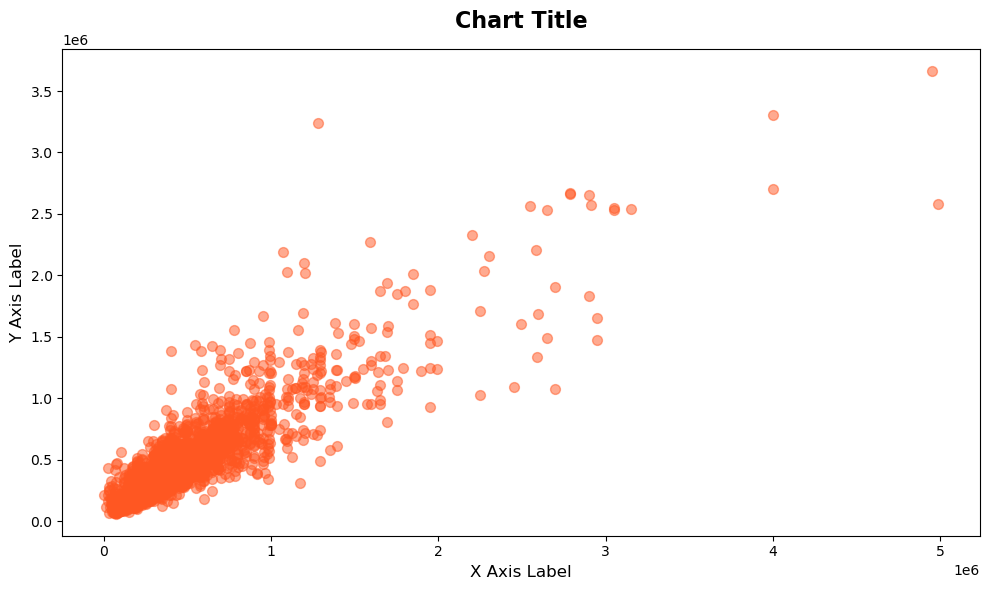

In [ ]:
# Visuals

fig, axes = plt.subplots(figsize=(10, 6)) 
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), sharey=True, gridspec_kw={"width_ratios": [2, 1]})  # left is 2x wider than right

# axes.bar(df["x"], df["y"], color="#4CAF50", edgecolor="white", width=0.6, alpha=0.8, label="Series B")
axes.scatter(y_test, predictions, color="#FF5722", s=50, alpha=0.5, label="Series C")
axes.scatter(y_test, predictions, color="#454EF9", s=50, alpha=0.5, label="Series C")


# Title and Labels
axes.set_title("Chart Title", fontsize=16, fontweight="bold", pad=15)
axes.set_xlabel("X Axis Label", fontsize=12)
axes.set_ylabel("Y Axis Label", fontsize=12)



fig.tight_layout()   
plt.show()

In [13]:
## Debug
## These two are just for testing:
#X_train_transformed = pipe.fit_transform(X_train, y_train)  # fit + transform in one call
#X_train_transformed.isnull().sum()
#X_train_transformed.dtypes
#X_test_temp = pipe[:2].transform(X_test)
#print(X_test_temp["median_PM2_by_zip"].isnull().sum())
#X_train_transformed.isnull().sum()

# debugging
#X_temp = pipe[:2].fit_transform(X_train, y_train)

# Force convert to float (what PolynomialFeatures does internally) and THEN check for NaN

""" arr = X_temp.to_numpy(dtype=float)
print("NaN per column:")
for i, col in enumerate(X_temp.columns):
    n = np.isnan(arr[:, i]).sum()
    if n > 0:
        print(f"  {col}: {n} NaNs")

X_test_temp = pipe[:2].transform(X_test)
print(X_test_temp["median_PM2_by_zip"].isnull().sum())
 """



' arr = X_temp.to_numpy(dtype=float)\nprint("NaN per column:")\nfor i, col in enumerate(X_temp.columns):\n    n = np.isnan(arr[:, i]).sum()\n    if n > 0:\n        print(f"  {col}: {n} NaNs")\n\nX_test_temp = pipe[:2].transform(X_test)\nprint(X_test_temp["median_PM2_by_zip"].isnull().sum())\n '

**Results of regression:**
**degree 1**
    # Random state = 42
    # R² train: 0.6256794000401746
    # R² test: 0.5492695496407698
    
    # Random state = 12
    #R² train: 0.6161491626116237
    #R² test: 0.600743423831813
    

**Degree 2**
    # Random state = 42
    # R² train: 0.7968084292045988
    # R² test: 0.7315113784072382
    
    # Random state = 41 
    #R² train: 0.7985596564261025
    #R² test: 0.7151671852041732

    # Random state = 40
    #R² train: 0.7924439204469289
    #R² test: 0.755818158719489
    
    # Random state = 24
    #R² train: 0.7957959106225108
    #R² test: 0.7501112547518086
    

**degree 3**
     Random state = 42
    #R² train: 0.85931256469144
    #R² test: 0.34970898009479756
    
    Random state = 24
    #R² train: 0.8539969793207055
    #R² test: 0.27661240794941444
    
    Random state = 24
    #R² train: 0.8536097063794973
    #R² test: 0.3580500597839166


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R² train: 0.9711331072437346
R² test: 0.7969211701165118


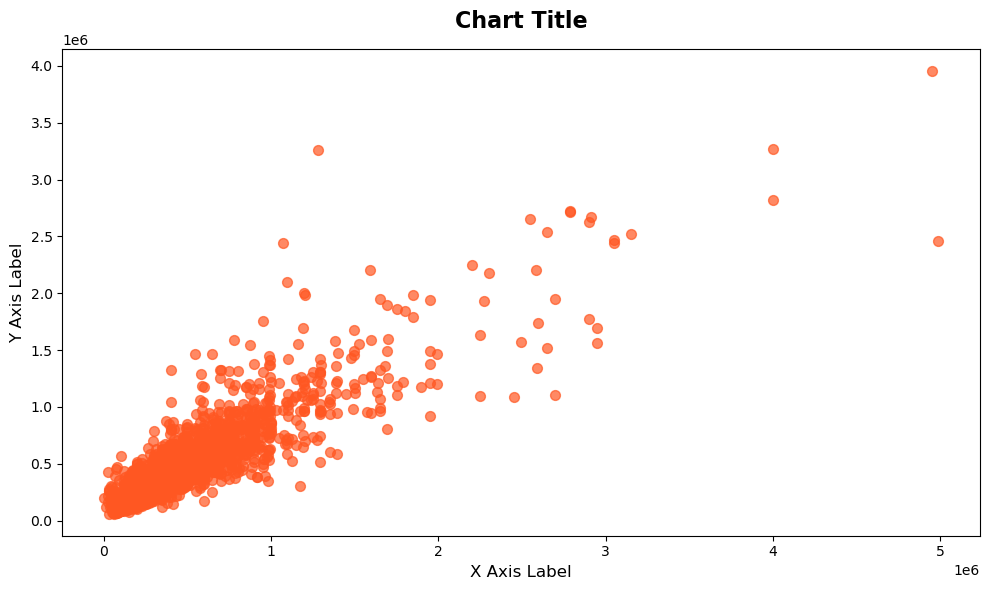

In [21]:
## Random Forest:

pipe_rf = Pipeline([
    ('zip_encode', ZipCodeTargetEncoder()),
    ('fill_nulls', NullFiller()),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, max_depth=20)),
])

pipe_rf.fit(X_train, y_train)  
predictions = pipe_rf.predict(X_test)
print("R² train:", pipe_rf.score(X_train, y_train))
print("R² test:", pipe_rf.score(X_test, y_test))




fig, axes = plt.subplots(figsize=(10, 6)) 
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), sharey=True, gridspec_kw={"width_ratios": [2, 1]})  # left is 2x wider than right

axes.scatter(y_test, predictions, color="#FF5722", s=50, alpha=0.7, label="Series C")
         

# Title and Labels
axes.set_title("Chart Title", fontsize=16, fontweight="bold", pad=15)
axes.set_xlabel("X Axis Label", fontsize=12)
axes.set_ylabel("Y Axis Label", fontsize=12)

# Options
# ax.grid(True, axis="y", linestyle="--", alpha=0.5)      # grid
# ax.legend(loc="upper right", fontsize=10, frameon=True) # legend
# ax.axhline(y=30, color="gray", linestyle=":", linewidth=1)  # horiz. ref line

fig.tight_layout()   
plt.show()

**Results of random Forest**

random state 42:
    R² train: 0.9742192537153849
    R² test: 0.7387784696084594

random state 24:
    R² train: 0.9714328807237207
    R² test: 0.7966149073198046

random state 23:
    R² train: 0.9730657240393344
    R² test: 0.7650872058345625



R² train: 0.9486781397019208
R² test: 0.7979622719831287


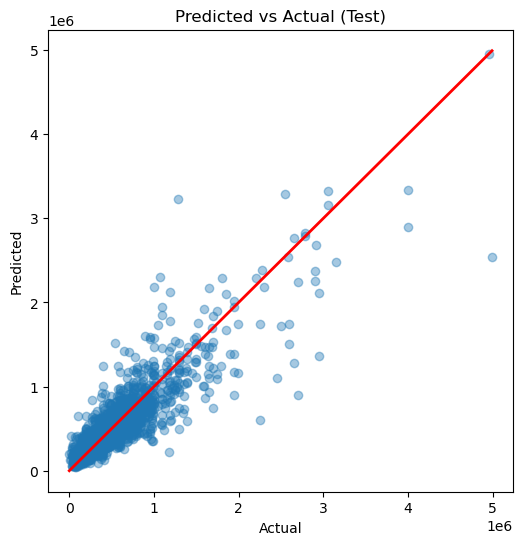

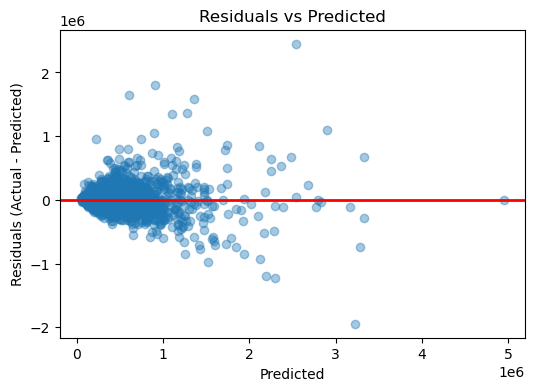

In [15]:
from xgboost import XGBRegressor

pipe_xgb = Pipeline([
    ('zip_encode', ZipCodeTargetEncoder()),
    ('fill_nulls', NullFiller()),
    ('model', XGBRegressor(n_estimators=100, random_state=42)),
])

pipe_xgb.fit(X_train, y_train.ravel())  # .ravel() on y_train flattens it from shape (n, 1) to (n,)
print("R² train:", pipe_xgb.score(X_train, y_train))
print("R² test:", pipe_xgb.score(X_test, y_test))

## Plotting it:
# predictions
y_pred = pipe_xgb.predict(X_test)

# 1) Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Test)")
plt.show()

# 2) Residuals plot
residuals = y_test.ravel() - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color="red", lw=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.show()


**XG BOOST Results**
random state 12
    R² train: 0.9477907274595597
    R² test: 0.8230988713042142

random state 17:
    R² train: 0.9527652322121626
    R² test: 0.7862409091161844

random state 23:
    R² train: 0.9520560373651522
    R² test: 0.7623187101111338
